In [42]:
################################
## Import Libaries

###########################
## Import Torch Libaries
import torch
import torch.nn as nn
from torch.utils.data import Dataset
from torchvision import transforms
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.utils.data import random_split
from torchvision import transforms
###########################
## Import standard libaries
import pandas as pd
import numpy as np
import os
import random
##########################
## Import PIL
from PIL import Image

#####################
## import SK learn libaries
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score
####################
## import matplot
import matplotlib.pyplot as plt

In [43]:
#####################
##Enable CUDA
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [44]:
######################
## import onnx runtime
import onnxruntime 
import onnxmltools
from skl2onnx.common.data_types import FloatTensorType

## View class

In [45]:
######################
## View Class

## we will use this class and its
## functions to flatten and fully connect
## our cnn layers and linear feed output layers
class View(nn.Module):
    
    def __init__(self, shape):
        
        super().__init__()
        self.shape = shape,

    def forward(self, x):
        return x.view(*self.shape)



## Read Emotion Data Set

In [46]:
class EmotionDataset(Dataset):
    def __init__(self, data_path, transform=None):
        ## path to dataset
        self.data_path = data_path
        ## inputs a PIL image
        self.transform = transform
        self.classes = os.listdir(data_path)
        ## put images and labels in an array
        self.images = []
        self.labels = []
        ## iterate trhoguh each emotion class ( folder )
        for i, emotion_class in enumerate(self.classes):
            class_path = os.path.join(data_path, emotion_class)
            ## iterate through each image in the folder
            for image_name in os.listdir(class_path):
                image_path = os.path.join(class_path, image_name)
                self.images.append(image_path)
                self.labels.append(i)

    ## number of samples in dataset            
    def __len__(self):
        return len(self.images)
    ##
    def __getitem__(self, index):
        ## get a sample from the dataset at
        ## the specified index
        image_path = self.images[index]
        ## map label to index
        label = self.labels[index]

        # Open the image
        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        # Convert label to a single index
        label = torch.tensor(label, dtype=torch.long)

        return image, label



In [47]:
data_path = './images'  
transform = transforms.Compose([
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
])

emotion_dataset = EmotionDataset(data_path=data_path, transform=transform)


In [48]:

index = 0
image, label = emotion_dataset[index]



In [49]:

image.shape


torch.Size([3, 48, 48])

In [50]:

label


tensor(0)

In [51]:
#######################
##  Custom CNN 3 convulutional layer model
class Classifier_CNN_3_Layers(nn.Module):
        def __init__(self):
            super(Classifier_CNN_3_Layers, self).__init__()
            ####################
            ### CNN layers
            
            ###############
            # 3 for RGB channel values
            self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1)
            self.pool1= nn.MaxPool2d(kernel_size=2, stride = 2)
            self.conv2 = nn.Conv2d(64,128, kernel_size=3, stride=1, padding=1)
            self.pool2 = nn.MaxPool2d(kernel_size=2, stride = 2)
            self.conv3 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
            self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
            ### Relu activation function
            self.relu = nn.ReLU()
            #####################
            ### Linear Layers
        
            self.fc1 = nn.Linear(256 * 6 * 6, 512)
            self.fc2 = nn.Linear(512, 1)
    
        def forward(self, x):
            x = self.conv1(x)
            x = self.relu(x)
            x = self.pool1(x)
            
            x = self.conv2(x)
            x = self.relu(x)
            x = self.pool2(x)
            
            x = self.conv3(x)
            x = self.relu(x)
            x = self.pool3(x)
            
            ## Flatten Into fully connected layers
            ## Via View command
            x = x.view(-1, 256 * 6 * 6)
            x = self.fc1(x)
            x = self.relu(x)
            x = self.fc2(x)
            return x



In [52]:
#######################
##  Custom CNN 5 convulutional layer model

### 5 layer model was not as successful as our 3 layer model
## it did not perform nearly as well
'''
class Classifier_CNN_5_Layers(nn.Module):
        def __init__(self):
            super(Classifier_CNN_5_Layers, self).__init__()
            self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1)
            self.pool1= nn.MaxPool2d(kernel_size=2, stride = 2)
            self.conv2 = nn.Conv2d(64,128, kernel_size=3, stride=1, padding=1)
            self.pool2 = nn.MaxPool2d(kernel_size=2, stride = 2)
            self.conv3 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
            self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
            self.conv4 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
            self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)
            self.conv5 = nn.Conv2d(512, 1024, kernel_size=3, padding=1)
            self.pool5 = nn.MaxPool2d(kernel_size=2, stride=2)
            self.relu = nn.ReLU()
            self.fc1 = nn.Linear(1024 * 6 * 6, 512)
            self.fc2 = nn.Linear(512, 1)
    
        def forward(self, x):
            x = self.conv1(x)
            x = self.relu(x)
            x = self.pool1(x)
            
            x = self.conv2(x)
            x = self.relu(x)
            x = self.pool2(x)
            
            x = self.conv3(x)
            x = self.relu(x)
            x = self.pool3(x)
            
            x = self.conv4(x)
            x = self.relu(x)
      
            
            x = self.conv5(x)
            x = self.relu(x)
 
            print(x.size()) 
            
            x = x.view(-1, 1024 * 6 * 6)
            x = self.fc1(x)
            x = self.relu(x)
            x = self.fc2(x)
            return x

'''

'\nclass Classifier_CNN_5_Layers(nn.Module):\n        def __init__(self):\n            super(Classifier_CNN_5_Layers, self).__init__()\n            self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1)\n            self.pool1= nn.MaxPool2d(kernel_size=2, stride = 2)\n            self.conv2 = nn.Conv2d(64,128, kernel_size=3, stride=1, padding=1)\n            self.pool2 = nn.MaxPool2d(kernel_size=2, stride = 2)\n            self.conv3 = nn.Conv2d(128, 256, kernel_size=3, padding=1)\n            self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)\n            self.conv4 = nn.Conv2d(256, 512, kernel_size=3, padding=1)\n            self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)\n            self.conv5 = nn.Conv2d(512, 1024, kernel_size=3, padding=1)\n            self.pool5 = nn.MaxPool2d(kernel_size=2, stride=2)\n            self.relu = nn.ReLU()\n            self.fc1 = nn.Linear(1024 * 6 * 6, 512)\n            self.fc2 = nn.Linear(512, 1)\n    \n        def forward(self, x):

In [53]:
###########################
##  Transform images to 48*48
data_path = './images'

# Define the transformations for your dataset
transform = transforms.Compose([
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

###########################

In [54]:
###########################
# Split the dataset into training and testing sets
train_size = int(0.8 * len(emotion_dataset))
test_size = len(emotion_dataset) - train_size
train_dataset, test_dataset = random_split(emotion_dataset, [train_size, test_size])
###########################

In [55]:
###########################
## Define Test and train data loaders

# Define batch size
batch_size = 32

# Create DataLoader instances for training and testing datasets
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

###########################

In [56]:
###########################
image.shape

## show image tensor shape



torch.Size([3, 48, 48])

In [57]:
%%time
##########################
## record time


## Create an instance of the model
## And optimizer

## change between 3 layers or 5 layers
cnn_classifier = Classifier_CNN_3_Layers()
#cnn_classifier = Classifier_CNN_5_Layers()
## send classifier to GPU
cnn_classifier.to(device)
## parameters and optimizer
optimizer = optim.SGD(cnn_classifier.parameters(), lr=0.1)
## since this is a binary classification problem
## we use BCE
criterion = nn.BCEWithLogitsLoss() 

## number of epochs
epochs = 100
# Training loop
for epoch in range(epochs):
    # Training
    cnn_classifier.train()
    for i, (images, labels) in enumerate(train_loader):
        images,  labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = cnn_classifier(images)
        ##Examine predicted happy or sad
        predicted_labels = (outputs >= 0.5).float()
        
        ## uncomment or comment to control
        ## predicted prints
        
        #print("Predictions:", predicted_labels)
        #print("True Labels:", labels)    
        
        loss = criterion(outputs.squeeze(), labels.float())
        loss.backward()
        optimizer.step()
        print(f"Epoch {epoch + 1}/{epochs}, Iteration {i + 1}/{len(train_loader)}, Loss: {loss.item()}")


Epoch 1/100, Iteration 1/25, Loss: 0.693541407585144
Epoch 1/100, Iteration 2/25, Loss: 0.6932429671287537
Epoch 1/100, Iteration 3/25, Loss: 0.6927651166915894
Epoch 1/100, Iteration 4/25, Loss: 0.6905962228775024
Epoch 1/100, Iteration 5/25, Loss: 0.6851251125335693
Epoch 1/100, Iteration 6/25, Loss: 0.7087315917015076
Epoch 1/100, Iteration 7/25, Loss: 0.6942877769470215
Epoch 1/100, Iteration 8/25, Loss: 0.6930266618728638
Epoch 1/100, Iteration 9/25, Loss: 0.6905868053436279
Epoch 1/100, Iteration 10/25, Loss: 0.7029446363449097
Epoch 1/100, Iteration 11/25, Loss: 0.6932113170623779
Epoch 1/100, Iteration 12/25, Loss: 0.69145268201828
Epoch 1/100, Iteration 13/25, Loss: 0.694406270980835
Epoch 1/100, Iteration 14/25, Loss: 0.6921801567077637
Epoch 1/100, Iteration 15/25, Loss: 0.6905195116996765
Epoch 1/100, Iteration 16/25, Loss: 0.6909390091896057
Epoch 1/100, Iteration 17/25, Loss: 0.6927680969238281
Epoch 1/100, Iteration 18/25, Loss: 0.691903829574585
Epoch 1/100, Iteration 1

Epoch 7/100, Iteration 8/25, Loss: 0.679063618183136
Epoch 7/100, Iteration 9/25, Loss: 0.6810536980628967
Epoch 7/100, Iteration 10/25, Loss: 0.6783595085144043
Epoch 7/100, Iteration 11/25, Loss: 0.7139387130737305
Epoch 7/100, Iteration 12/25, Loss: 0.6915184259414673
Epoch 7/100, Iteration 13/25, Loss: 0.6886001229286194
Epoch 7/100, Iteration 14/25, Loss: 0.6863129138946533
Epoch 7/100, Iteration 15/25, Loss: 0.6940111517906189
Epoch 7/100, Iteration 16/25, Loss: 0.6803589463233948
Epoch 7/100, Iteration 17/25, Loss: 0.6784292459487915
Epoch 7/100, Iteration 18/25, Loss: 0.6940622329711914
Epoch 7/100, Iteration 19/25, Loss: 0.703095555305481
Epoch 7/100, Iteration 20/25, Loss: 0.6840106844902039
Epoch 7/100, Iteration 21/25, Loss: 0.6961453557014465
Epoch 7/100, Iteration 22/25, Loss: 0.687391996383667
Epoch 7/100, Iteration 23/25, Loss: 0.6876288056373596
Epoch 7/100, Iteration 24/25, Loss: 0.689699649810791
Epoch 7/100, Iteration 25/25, Loss: 0.6857234835624695
Epoch 8/100, Ite

Epoch 13/100, Iteration 9/25, Loss: 0.6555029153823853
Epoch 13/100, Iteration 10/25, Loss: 0.610511064529419
Epoch 13/100, Iteration 11/25, Loss: 0.7272990942001343
Epoch 13/100, Iteration 12/25, Loss: 0.6354163289070129
Epoch 13/100, Iteration 13/25, Loss: 0.672924280166626
Epoch 13/100, Iteration 14/25, Loss: 0.6579741835594177
Epoch 13/100, Iteration 15/25, Loss: 0.6463322639465332
Epoch 13/100, Iteration 16/25, Loss: 0.682353138923645
Epoch 13/100, Iteration 17/25, Loss: 0.770751416683197
Epoch 13/100, Iteration 18/25, Loss: 0.6516320705413818
Epoch 13/100, Iteration 19/25, Loss: 0.6266310214996338
Epoch 13/100, Iteration 20/25, Loss: 0.6812593936920166
Epoch 13/100, Iteration 21/25, Loss: 0.6747685670852661
Epoch 13/100, Iteration 22/25, Loss: 0.6417949199676514
Epoch 13/100, Iteration 23/25, Loss: 0.6837020516395569
Epoch 13/100, Iteration 24/25, Loss: 0.6297996044158936
Epoch 13/100, Iteration 25/25, Loss: 0.6724971532821655
Epoch 14/100, Iteration 1/25, Loss: 0.647281408309936

Epoch 19/100, Iteration 8/25, Loss: 0.5596818923950195
Epoch 19/100, Iteration 9/25, Loss: 0.6116244792938232
Epoch 19/100, Iteration 10/25, Loss: 0.697450578212738
Epoch 19/100, Iteration 11/25, Loss: 0.6041842699050903
Epoch 19/100, Iteration 12/25, Loss: 0.6124886274337769
Epoch 19/100, Iteration 13/25, Loss: 0.6107906103134155
Epoch 19/100, Iteration 14/25, Loss: 0.49456560611724854
Epoch 19/100, Iteration 15/25, Loss: 0.6313050985336304
Epoch 19/100, Iteration 16/25, Loss: 0.5763038396835327
Epoch 19/100, Iteration 17/25, Loss: 0.601928174495697
Epoch 19/100, Iteration 18/25, Loss: 0.6028170585632324
Epoch 19/100, Iteration 19/25, Loss: 0.5242634415626526
Epoch 19/100, Iteration 20/25, Loss: 0.5332034826278687
Epoch 19/100, Iteration 21/25, Loss: 0.50214022397995
Epoch 19/100, Iteration 22/25, Loss: 0.5690567493438721
Epoch 19/100, Iteration 23/25, Loss: 0.5888974666595459
Epoch 19/100, Iteration 24/25, Loss: 0.8029611110687256
Epoch 19/100, Iteration 25/25, Loss: 0.75302135944366

Epoch 25/100, Iteration 6/25, Loss: 0.5010027885437012
Epoch 25/100, Iteration 7/25, Loss: 0.42022430896759033
Epoch 25/100, Iteration 8/25, Loss: 0.5232798457145691
Epoch 25/100, Iteration 9/25, Loss: 0.5543439388275146
Epoch 25/100, Iteration 10/25, Loss: 0.40162602066993713
Epoch 25/100, Iteration 11/25, Loss: 0.4789721965789795
Epoch 25/100, Iteration 12/25, Loss: 0.43431222438812256
Epoch 25/100, Iteration 13/25, Loss: 0.4177982807159424
Epoch 25/100, Iteration 14/25, Loss: 0.4548580050468445
Epoch 25/100, Iteration 15/25, Loss: 0.7315599918365479
Epoch 25/100, Iteration 16/25, Loss: 0.517202615737915
Epoch 25/100, Iteration 17/25, Loss: 0.6552850008010864
Epoch 25/100, Iteration 18/25, Loss: 0.5742580890655518
Epoch 25/100, Iteration 19/25, Loss: 0.533467173576355
Epoch 25/100, Iteration 20/25, Loss: 0.5926257967948914
Epoch 25/100, Iteration 21/25, Loss: 0.4672374129295349
Epoch 25/100, Iteration 22/25, Loss: 0.5914402008056641
Epoch 25/100, Iteration 23/25, Loss: 0.504329800605

...

Epoch 77/100, Iteration 21/25, Loss: 0.00055703055113554
Epoch 77/100, Iteration 22/25, Loss: 0.0009015955729410052
Epoch 77/100, Iteration 23/25, Loss: 0.0006343041313812137
Epoch 77/100, Iteration 24/25, Loss: 0.000515258579980582
Epoch 77/100, Iteration 25/25, Loss: 0.0007282787701115012
Epoch 78/100, Iteration 1/25, Loss: 0.0008328344556502998
Epoch 78/100, Iteration 2/25, Loss: 0.0005343329394236207
Epoch 78/100, Iteration 3/25, Loss: 0.00040499624446965754
Epoch 78/100, Iteration 4/25, Loss: 0.00042104031308554113
Epoch 78/100, Iteration 5/25, Loss: 0.00029502928373403847
Epoch 78/100, Iteration 6/25, Loss: 0.0003501850296743214
Epoch 78/100, Iteration 7/25, Loss: 0.00048049440374597907
Epoch 78/100, Iteration 8/25, Loss: 0.0008662381442263722
Epoch 78/100, Iteration 9/25, Loss: 0.0004979523364454508
Epoch 78/100, Iteration 10/25, Loss: 0.00040404885658062994
Epoch 78/100, Iteration 11/25, Loss: 0.0004406207299325615
Epoch 78/100, Iteration 12/25, Loss: 0.0009513887926004827
Epoc

Epoch 83/100, Iteration 11/25, Loss: 0.00019234327191952616
Epoch 83/100, Iteration 12/25, Loss: 0.00024500966537743807
Epoch 83/100, Iteration 13/25, Loss: 0.0005617314600385725
Epoch 83/100, Iteration 14/25, Loss: 0.00045971182407811284
Epoch 83/100, Iteration 15/25, Loss: 0.0003366087330505252
Epoch 83/100, Iteration 16/25, Loss: 0.0003588586114346981
Epoch 83/100, Iteration 17/25, Loss: 0.0009797562379390001
Epoch 83/100, Iteration 18/25, Loss: 0.0004377050790935755
Epoch 83/100, Iteration 19/25, Loss: 0.00043172528967261314
Epoch 83/100, Iteration 20/25, Loss: 0.0003859574790112674
Epoch 83/100, Iteration 21/25, Loss: 0.0002371470327489078
Epoch 83/100, Iteration 22/25, Loss: 0.0002561012515798211
Epoch 83/100, Iteration 23/25, Loss: 0.00047463193186558783
Epoch 83/100, Iteration 24/25, Loss: 0.00028630951419472694
Epoch 83/100, Iteration 25/25, Loss: 0.0005536412354558706
Epoch 84/100, Iteration 1/25, Loss: 0.0004841158806812018
Epoch 84/100, Iteration 2/25, Loss: 0.0002629252267

Epoch 89/100, Iteration 3/25, Loss: 0.0002816740015987307
Epoch 89/100, Iteration 4/25, Loss: 0.00038151181070134044
Epoch 89/100, Iteration 5/25, Loss: 0.0005509271286427975
Epoch 89/100, Iteration 6/25, Loss: 0.00044730008812621236
Epoch 89/100, Iteration 7/25, Loss: 0.000308290240354836
Epoch 89/100, Iteration 8/25, Loss: 0.00027183318161405623
Epoch 89/100, Iteration 9/25, Loss: 0.0004583713016472757
Epoch 89/100, Iteration 10/25, Loss: 0.0005855737254023552
Epoch 89/100, Iteration 11/25, Loss: 0.00018335063941776752
Epoch 89/100, Iteration 12/25, Loss: 0.00011000708036590368
Epoch 89/100, Iteration 13/25, Loss: 0.00011193724640179425
Epoch 89/100, Iteration 14/25, Loss: 0.00047822538181208074
Epoch 89/100, Iteration 15/25, Loss: 0.0003481385647319257
Epoch 89/100, Iteration 16/25, Loss: 0.00044127984438091516
Epoch 89/100, Iteration 17/25, Loss: 0.0003658205969259143
Epoch 89/100, Iteration 18/25, Loss: 0.0005840338999405503
Epoch 89/100, Iteration 19/25, Loss: 0.00015363036072812

Epoch 94/100, Iteration 17/25, Loss: 6.534476415254176e-05
Epoch 94/100, Iteration 18/25, Loss: 0.0002663570048753172
Epoch 94/100, Iteration 19/25, Loss: 0.0002661878243088722
Epoch 94/100, Iteration 20/25, Loss: 0.00034100288758054376
Epoch 94/100, Iteration 21/25, Loss: 0.00016555647016502917
Epoch 94/100, Iteration 22/25, Loss: 7.581216050311923e-05
Epoch 94/100, Iteration 23/25, Loss: 0.0004355964483693242
Epoch 94/100, Iteration 24/25, Loss: 0.0003779748803935945
Epoch 94/100, Iteration 25/25, Loss: 0.0003992329293396324
Epoch 95/100, Iteration 1/25, Loss: 0.00032646750332787633
Epoch 95/100, Iteration 2/25, Loss: 0.00015549306408502162
Epoch 95/100, Iteration 3/25, Loss: 0.00042476621456444263
Epoch 95/100, Iteration 4/25, Loss: 0.0001347863581031561
Epoch 95/100, Iteration 5/25, Loss: 0.00039778187056072056
Epoch 95/100, Iteration 6/25, Loss: 0.0003862438607029617
Epoch 95/100, Iteration 7/25, Loss: 0.00011566519970074296
Epoch 95/100, Iteration 8/25, Loss: 0.000232440448598936

Epoch 100/100, Iteration 11/25, Loss: 0.0002720311749726534
Epoch 100/100, Iteration 12/25, Loss: 0.0002684424980543554
Epoch 100/100, Iteration 13/25, Loss: 0.0004240630369167775
Epoch 100/100, Iteration 14/25, Loss: 0.0003605866222642362
Epoch 100/100, Iteration 15/25, Loss: 0.0002554807288106531
Epoch 100/100, Iteration 16/25, Loss: 0.00028601870872080326
Epoch 100/100, Iteration 17/25, Loss: 0.0003063527401536703
Epoch 100/100, Iteration 18/25, Loss: 0.0002731861313804984
Epoch 100/100, Iteration 19/25, Loss: 0.00025090263807214797
Epoch 100/100, Iteration 20/25, Loss: 0.0004341004532761872
Epoch 100/100, Iteration 21/25, Loss: 0.00011647703649941832
Epoch 100/100, Iteration 22/25, Loss: 0.0003129866090603173
Epoch 100/100, Iteration 23/25, Loss: 0.00013693446817342192
Epoch 100/100, Iteration 24/25, Loss: 0.0001952762686414644
Epoch 100/100, Iteration 25/25, Loss: 0.00015215284656733274
CPU times: total: 1min 28s
Wall time: 1min 29s


## Evaluate Model On The Train Data loader

In [58]:
##########################
## evaluate train
def evaluate_model(model, train_loader, device):
    ## Set the model to evaluation mode
    cnn_classifier.eval() 
    all_predictions = []
    all_targets = []

    with torch.no_grad():
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            _, predictions = torch.max(outputs, 1)

            all_predictions.extend(predictions.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
    ## sk learn performance metrics
    accuracy  = accuracy_score(all_targets, all_predictions)
    confmat   = confusion_matrix(y_true=all_targets, y_pred=all_predictions)
    precision = precision_score(y_true=all_targets, y_pred=all_predictions, average='weighted', zero_division=1)
    recall    = recall_score(y_true=all_targets, y_pred=all_predictions, average='weighted', zero_division=1)
    f1 = f1_score(y_true=all_targets, y_pred=all_predictions, average='weighted')
    ### display metrics
    print(f'Confusion Matrix:\n{confmat}')
    print(f'Accuracy: {accuracy:.2f}')
    print(f'Precision: {precision:.2f}')
    print(f'Recall: {recall:.2f}')
    print(f'F1-score: {f1:.2f}')


In [59]:
evaluate_model(cnn_classifier, train_loader, device)

Confusion Matrix:
[[401   0]
 [399   0]]
Accuracy: 0.50
Precision: 0.75
Recall: 0.50
F1-score: 0.33


## Evaluate Model On The Test Data loader

In [69]:
########################
## evaluate model based on test data loader
def evaluate_model(model, test_loader, device):
    ## Set the model to evaluation mode
    cnn_classifier.eval() 
    all_predictions = []
    all_targets = []

    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            _, predictions = torch.max(outputs, 1)

            all_predictions.extend(predictions.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
    ## sk learn performance metrics
    accuracy  = accuracy_score(all_targets, all_predictions)
    confmat   = confusion_matrix(y_true=all_targets, y_pred=all_predictions)
    precision = precision_score(y_true=all_targets, y_pred=all_predictions, average='weighted', zero_division=1)
    recall    = recall_score(y_true=all_targets, y_pred=all_predictions, average='weighted', zero_division=1)
    f1 = f1_score(y_true=all_targets, y_pred=all_predictions, average='weighted')
    ## Display sk learn performance metrics
    print(f'Confusion Matrix:\n{confmat}')
    print(f'Accuracy: {accuracy:.2f}')
    print(f'Precision: {precision:.2f}')
    print(f'Recall: {recall:.2f}')
    print(f'F1-score: {f1:.2f}')


In [70]:
evaluate_model(cnn_classifier, test_loader, device)

Confusion Matrix:
[[ 99   0]
 [101   0]]
Accuracy: 0.49
Precision: 0.75
Recall: 0.49
F1-score: 0.33


## Test based off random image from train dataset

Actual Class: happy, Predicted Class: happy, Correct: True


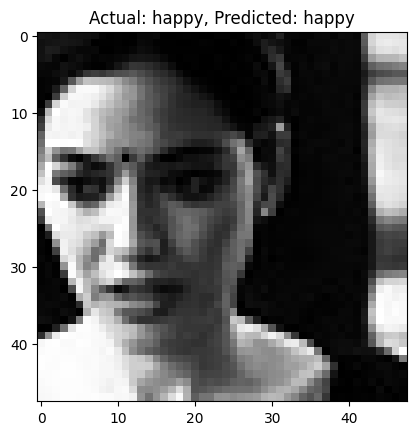

In [71]:
###########################
## Test on train data
cnn_classifier.eval()
# Define class names
class_names = ["happy", "sad"] # Add or modify as needed
# Get a random index from the test set
random_index = random.randint(0, len(train_dataset) - 1)
# Get the image and label at the random index
image, label = train_dataset[random_index]
image = image.to(device)
label = label.to(device)


output = cnn_classifier(image.unsqueeze(0))  # Unsqueeze to add batch dimension

# Apply threshold for binary classification
predicted_label = 1 if output > 0.5 else 0

# Convert labels to class names
actual_class = class_names[int(label)]
predicted_class = class_names[predicted_label]

# Check if the prediction is correct
is_correct = predicted_label == int(label)

# Print results
print(f"Actual Class: {actual_class}, Predicted Class: {predicted_class}, Correct: {is_correct}")

# Display the image
image = image.cpu().permute(1, 2, 0).numpy()  # Convert to numpy and rearrange dimensions
plt.imshow(image)
plt.title(f"Actual: {actual_class}, Predicted: {predicted_class}")
plt.show()


## Test From an image in the Test Dataset

In [72]:
cnn_classifier.eval()
random_index = random.randint(0, len(test_dataset) - 1)
image, label = test_dataset[random_index]
image = image.to(device)
label = label.to(device)


In [73]:
image.shape

torch.Size([3, 48, 48])

In [74]:
label

tensor(1, device='cuda:0')

Actual Label: 1, Predicted Label: 1, Correct: True


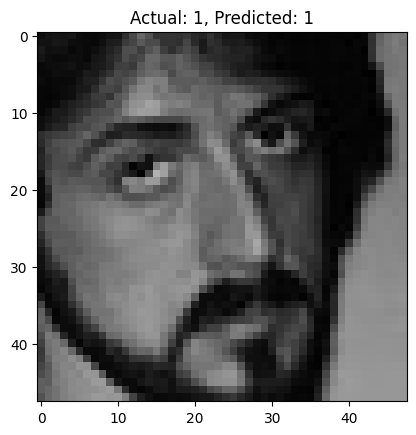

In [75]:
# Forward pass
output = cnn_classifier(image.unsqueeze(0))  
# Unsqueeze to add batch dimension

# Apply threshold for binary classification
predicted_label = 1 if output > 0.5 else 0

# Convert labels to numpy arrays for easy comparison
actual_label = label.cpu().numpy()

# Check if the prediction is correct
is_correct = predicted_label == actual_label

# Print results
print(f"Actual Label: {actual_label}, Predicted Label: {predicted_label}, Correct: {is_correct}")

# Display the image
image = image.cpu().permute(1, 2, 0).numpy()  
# Convert to numpy and rearrange dimensions
plt.imshow(image)
plt.title(f"Actual: {actual_label}, Predicted: {predicted_label}")
plt.show()


In [80]:
cnn_classifier.eval()

# Define class names
class_names = ["happy", "sad"]  # Add or modify as needed

# Get a random index from the test set
random_index = random.randint(0, len(test_dataset) - 1)

# Get the image and label at the random index
image, label = test_dataset[random_index]
image = image.to(device)
label = label.to(device)



Actual Class: happy, Predicted Class: happy, Correct: True


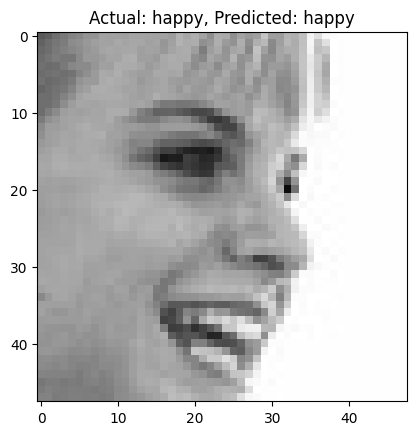

In [81]:
output = cnn_classifier(image.unsqueeze(0))  # Unsqueeze to add batch dimension

# Apply threshold for binary classification
predicted_label = 1 if output > 0.5 else 0

# Convert labels to class names
actual_class = class_names[int(label)]
predicted_class = class_names[predicted_label]

# Check if the prediction is correct
is_correct = predicted_label == int(label)

# Print results
print(f"Actual Class: {actual_class}, Predicted Class: {predicted_class}, Correct: {is_correct}")

# Display the image
image = image.cpu().permute(1, 2, 0).numpy()  # Convert to numpy and rearrange dimensions
plt.imshow(image)
plt.title(f"Actual: {actual_class}, Predicted: {predicted_class}")
plt.show()


## ONNX


In [ ]:
import torch.onnx
import torchvision.models as models

# Example: Load a pre-trained ResNet model
cnn_classifier  = models.resnet18(pretrained=True)


dummy_input = torch.randn(1, 3, 48, 48)

# Export the model to ONNX format
onnx_path = "emotion_recognition_model.onnx"
torch.onnx.export(cnn_classifier, dummy_input, onnx_path, verbose=True, input_names=['input'], output_names=['output'])
